# ✈️ Dự Báo Trễ Chuyến Bay Mỹ — XGBoost

**Môn:** Hệ thống hỗ trợ quyết định / Data Warehouse  
**Giai đoạn 3:** AI / Data Mining  
**Mô hình:** XGBoost Classifier  
**Target:** Dự đoán chuyến bay có bị trễ > 15 phút không (nhị phân 0/1)

---

## Luồng xử lý
```
SQL Server DW → Load Data → EDA & Visualize → Preprocessing → Train XGBoost → Evaluate → Save Model
```

## 0. Cài đặt thư viện

In [ ]:
import subprocess, sys
pkgs = ['pandas', 'xgboost', 'scikit-learn', 'pyodbc', 'joblib',
        'matplotlib', 'seaborn', 'plotly']
for p in pkgs:
    try:
        __import__(p.replace('-','_'))
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', p], check=True)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pyodbc
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier, plot_importance

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
PALETTE = ['#00d2ff', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6', '#1abc9c']

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

print('Import OK')

✅ Import OK


## 1. Kết nối SQL Server (Docker)

| Thông tin | Giá trị |
|---|---|
| Container | `flight-dw-sqlserver` |
| Port | 1433 |
| Database | DataWarehouse |
| Schema | DataWarehouse |

In [ ]:
# ─── Config ────────────────────────────────────────────────────────
SERVER   = '127.0.0.1,1433'
DATABASE = 'DataWarehouse'
SCHEMA   = 'DataWarehouse'
PASSWORD = 'FlightDW@2024'

# Auto-detect ODBC driver
_DRIVERS = [
    'ODBC Driver 18 for SQL Server',
    'ODBC Driver 17 for SQL Server',
    'SQL Server',
]

def get_conn():
    for drv in _DRIVERS:
        for encrypt in ['yes', 'no', '']:
            try:
                extra = f'TrustServerCertificate=yes;Encrypt={encrypt};' if encrypt else ''
                return pyodbc.connect(
                    f'DRIVER={{{drv}}};SERVER={SERVER};DATABASE={DATABASE};'
                    f'UID=SA;PWD={PASSWORD};{extra}'
                )
            except:
                continue
    raise RuntimeError('Không kết nối được! Chạy: docker ps để kiểm tra.')

def query(sql):
    """Chạy SQL"""
    conn = get_conn()
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

conn = get_conn()
cur = conn.cursor()
cur.execute('SELECT @@VERSION')
ver = cur.fetchone()[0].split('\n')[0]
conn.close()
print(f'Kết nối thành công!')
print(f'   SQL Server: {ver}')

✅ Kết nối thành công!
   SQL Server: Microsoft SQL Server 2022 (RTM-CU24-GDR) (KB5083252) - 16.0.4250.1 (X64) 


## 2. Tổng quan Data Warehouse

In [4]:
# ─── Đếm rows từng bảng ────────────────────────────────────────────
tables = ['Fact_Flight', 'Dim_Airline', 'Dim_Airport',
          'Dim_Date', 'Dim_Time', 'Dim_Delay_Category', 'Dim_Cancellation']

conn = get_conn()
cur  = conn.cursor()
counts = {}
for t in tables:
    cur.execute(f'SELECT COUNT(*) FROM [{SCHEMA}].[{t}]')
    counts[t] = cur.fetchone()[0]
conn.close()

df_counts = pd.DataFrame(list(counts.items()), columns=['Bảng', 'Số dòng'])
df_counts['Số dòng (M)'] = df_counts['Số dòng'].apply(lambda x: f'{x/1e6:.3f}M' if x > 1000 else str(x))
print(df_counts.to_string(index=False))

              Bảng  Số dòng Số dòng (M)
       Fact_Flight  1048571      1.049M
       Dim_Airline       15          15
       Dim_Airport      668         668
          Dim_Date    11323      0.011M
          Dim_Time     1440      0.001M
Dim_Delay_Category        6           6
  Dim_Cancellation        6           6


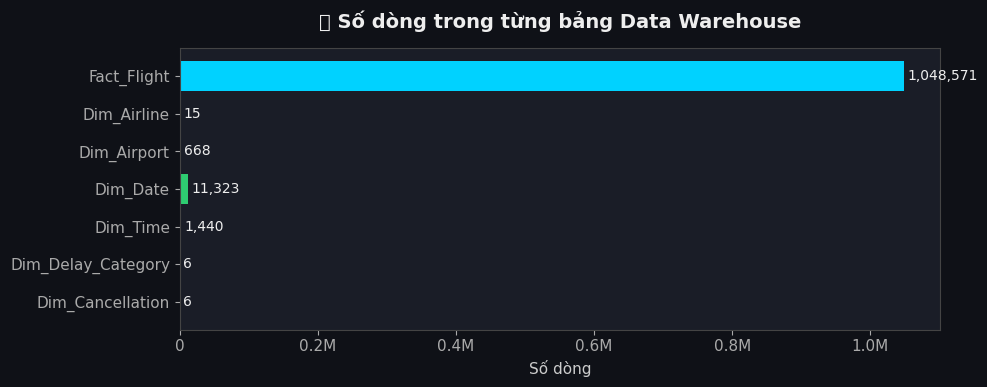

In [5]:
# ─── Visualize row counts ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

bars = ax.barh(df_counts['Bảng'], df_counts['Số dòng'],
               color=PALETTE, edgecolor='none')

# Label số lượng
for bar, val in zip(bars, df_counts['Số dòng']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, color='#eee')

ax.set_xlabel('Số dòng')
ax.set_title('📊 Số dòng trong từng bảng Data Warehouse', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x > 0 else '0'))
plt.tight_layout()
plt.show()

## 3. Load dữ liệu từ Data Warehouse

JOIN `Fact_Flight` với các bảng Dim để lấy features cần thiết cho model.

In [ ]:
# ─── Query toàn bộ data (hoặc giới hạn nếu máy yếu) ───────────────
LOAD_ALL = True
TOP_CLAUSE = '' if LOAD_ALL else 'TOP 300000'

SQL = f"""
SELECT {TOP_CLAUSE}
    -- Thời gian (từ Dim_Date)
    d.month,
    d.day_of_week,
    d.day_of_month,
    d.quarter,
    CAST(d.is_weekend AS INT)  AS is_weekend,
    d.year,

    -- Giờ bay (từ Dim_Time)
    t.hour                     AS dep_hour,
    t.period                   AS dep_period,

    -- Hãng bay (từ Dim_Airline)
    a.op_unique_carrier        AS carrier,

    -- Sân bay origin (từ Dim_Airport)
    ap_o.airport_code          AS origin_airport,
    ap_o.state_nm              AS origin_state,

    -- Sân bay destination (từ Dim_Airport)
    ap_d.airport_code          AS dest_airport,
    ap_d.state_nm              AS dest_state,

    -- Measures (từ Fact_Flight)
    f.distance,
    f.dep_delay,
    f.arr_delay,

    -- Phân loại nguyên nhân trễ
    ISNULL(f.carrier_delay, 0)       AS carrier_delay,
    ISNULL(f.weather_delay, 0)       AS weather_delay,
    ISNULL(f.nas_delay, 0)           AS nas_delay,
    ISNULL(f.security_delay, 0)      AS security_delay,
    ISNULL(f.late_aircraft_delay, 0) AS late_aircraft_delay

FROM [{SCHEMA}].[Fact_Flight]  f
JOIN [{SCHEMA}].[Dim_Date]     d    ON f.date_sk            = d.date_sk
JOIN [{SCHEMA}].[Dim_Time]     t    ON f.dep_time_sk        = t.time_sk
JOIN [{SCHEMA}].[Dim_Airline]  a    ON f.airline_sk         = a.airline_sk
JOIN [{SCHEMA}].[Dim_Airport]  ap_o ON f.origin_airport_sk  = ap_o.airport_sk
JOIN [{SCHEMA}].[Dim_Airport]  ap_d ON f.dest_airport_sk    = ap_d.airport_sk
WHERE f.cancelled = 0
  AND f.arr_delay IS NOT NULL
"""

print(f'⏳ Đang load {"toàn bộ" if LOAD_ALL else "300k"} rows từ SQL Server...')
df = query(SQL)
print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

⏳ Đang load toàn bộ rows từ SQL Server...


✅ Loaded: 1,025,183 rows × 21 columns


,month,day_of_week,day_of_month,quarter,is_weekend,year,dep_hour,dep_period,carrier,origin_airport,...,dest_airport,dest_state,distance,dep_delay,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,1,2,1,1,0,2024,12,Afternoon,9E,JFK,...,DTW,Michigan,509,-5,-19,0,0,0,0,0
1,1,2,1,1,0,2024,10,Morning,9E,MSP,...,CLE,Ohio,622,-14,-30,0,0,0,0,0
2,1,2,1,1,0,2024,14,Afternoon,9E,JFK,...,RIC,Virginia,288,-4,-20,0,0,0,0,0


## 4. EDA — Phân tích khám phá dữ liệu

In [7]:
# ─── 4.1 Tổng quan schema & kiểu dữ liệu ─────────────────────────
print('📋 Kiểu dữ liệu:')
print(df.dtypes.to_string())
print(f'\n📏 Shape: {df.shape}')
print(f'\n💾 Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

📋 Kiểu dữ liệu:
month                   int64
day_of_week             int64
day_of_month            int64
quarter                 int64
is_weekend              int64
year                    int64
dep_hour                int64
dep_period             object
carrier                object
origin_airport         object
origin_state           object
dest_airport           object
dest_state             object
distance                int64
dep_delay               int64
arr_delay               int64
carrier_delay           int64
weather_delay           int64
nas_delay               int64
security_delay          int64
late_aircraft_delay     int64

📏 Shape: (1025183, 21)



💾 Memory: 435.7 MB


In [ ]:
# ─── 4.2 Kiểm tra NULL ────────────────────────────────────────────
null_info = df.isnull().sum()
null_info = null_info[null_info > 0]

if null_info.empty:
    print('Không có NULL values trong dataset!')
else:
    print('Có NULL values:')
    null_pct = (null_info / len(df) * 100).round(2)
    print(pd.DataFrame({'null_count': null_info, 'null_%': null_pct}))

✅ Không có NULL values trong dataset!


In [ ]:
# ─── 4.3 Thống kê arr_delay ───────────────────────────────────────
print('Thống kê arr_delay (phút):')
print(df['arr_delay'].describe().to_frame().T.to_string())

# Phân tích percentile
percs = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(df['arr_delay'].dropna(), percs)
print('\nPercentiles:')
for p, v in zip(percs, pct_vals):
    print(f'  P{p:>2}: {v:>8.1f} phút')

📈 Thống kê arr_delay (phút):
               count  mean   std     min    25%   50%  75%     max
arr_delay 1025183.00  5.55 58.82 -117.00 -17.00 -7.00 9.00 2833.00

Percentiles:
  P 1:    -42.0 phút
  P 5:    -30.0 phút
  P10:    -25.0 phút
  P25:    -17.0 phút
  P50:     -7.0 phút
  P75:      9.0 phút
  P90:     40.0 phút
  P95:     78.0 phút
  P99:    211.0 phút


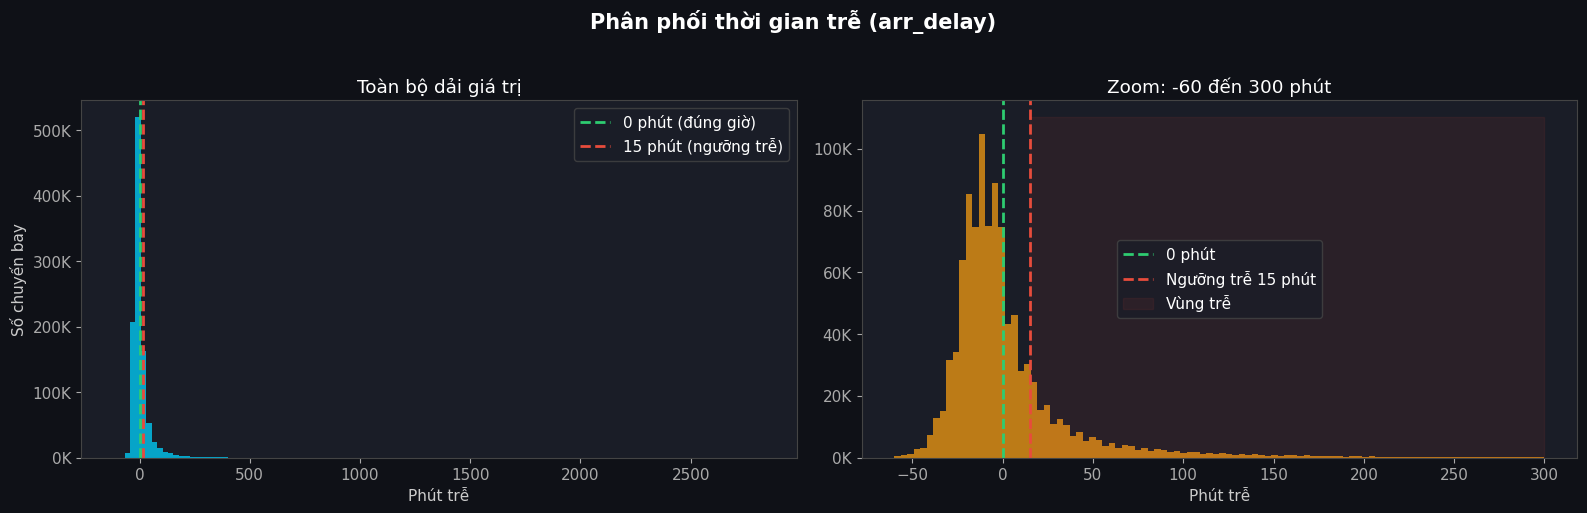

   Số chuyến trễ > 15 phút: 198,643 (19.4%)


In [ ]:
# ─── 4.4 Histogram arr_delay ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Phân phối thời gian trễ (arr_delay)', fontsize=15,
             fontweight='bold', color='white', y=1.02)

ax = axes[0]
ax.set_facecolor('#1a1d27')
ax.hist(df['arr_delay'], bins=120, color='#00d2ff', alpha=0.75, edgecolor='none')
ax.axvline(0,  color='#2ecc71', lw=2, ls='--', label='0 phút (đúng giờ)')
ax.axvline(15, color='#e74c3c', lw=2, ls='--', label='15 phút (ngưỡng trễ)')
ax.set_title('Toàn bộ dải giá trị', color='white')
ax.set_xlabel('Phút trễ')
ax.set_ylabel('Số chuyến bay')
ax.legend(facecolor='#1a1d27', edgecolor='#444', labelcolor='white')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

ax = axes[1]
ax.set_facecolor('#1a1d27')
clip = df[df['arr_delay'].between(-60, 300)]
ax.hist(clip['arr_delay'], bins=100, color='#f39c12', alpha=0.75, edgecolor='none')
ax.axvline(0,  color='#2ecc71', lw=2, ls='--', label='0 phút')
ax.axvline(15, color='#e74c3c', lw=2, ls='--', label='Ngưỡng trễ 15 phút')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1e5],
                  15, 300, alpha=0.08, color='#e74c3c', label='Vùng trễ')
ax.set_title('Zoom: -60 đến 300 phút', color='white')
ax.set_xlabel('Phút trễ')
ax.legend(facecolor='#1a1d27', edgecolor='#444', labelcolor='white')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()
print(f'   Số chuyến trễ > 15 phút: {(df["arr_delay"] > 15).sum():,} '
      f'({(df["arr_delay"] > 15).mean()*100:.1f}%)')

In [ ]:
df['is_delayed'] = (df['arr_delay'] > 15).astype(int)
delay_rate = df['is_delayed'].mean() * 100
on_time_rate = 100 - delay_rate

print(f'🎯 Phân bố nhãn (is_delayed):')
print(f'   Đúng giờ (0): {(df["is_delayed"]==0).sum():>8,}  ({on_time_rate:.1f}%)')
print(f'   Trễ      (1): {(df["is_delayed"]==1).sum():>8,}  ({delay_rate:.1f}%)')
print(f'\n   scale_pos_weight đề xuất = {on_time_rate/delay_rate:.2f}')

🎯 Phân bố nhãn (is_delayed):
   Đúng giờ (0):  826,540  (80.6%)
   Trễ      (1):  198,643  (19.4%)

   scale_pos_weight đề xuất = 4.16


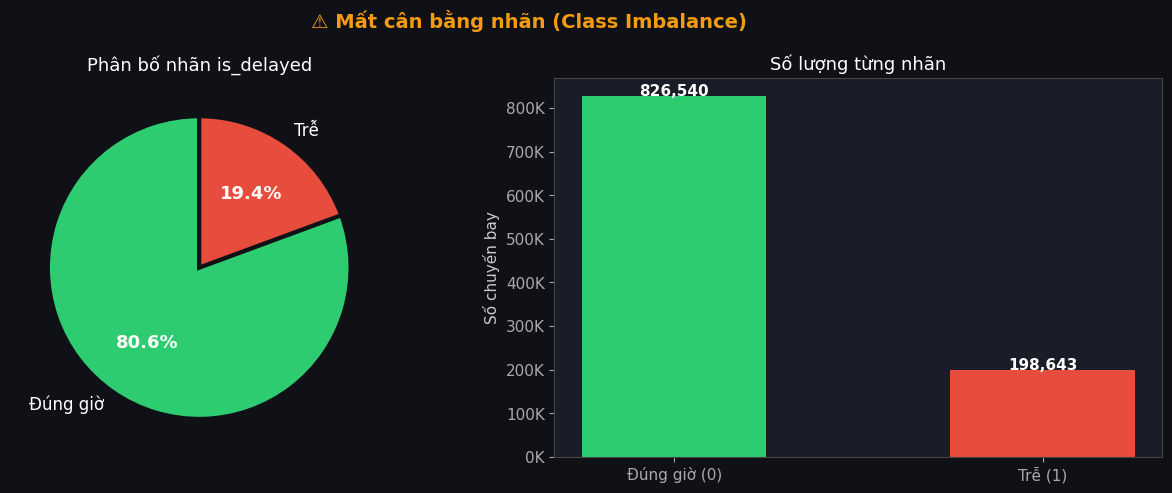

In [12]:
# ─── 4.6 Visualize class distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

# Pie chart
ax = axes[0]
ax.set_facecolor('#1a1d27')
wedges, texts, autotexts = ax.pie(
    [on_time_rate, delay_rate],
    labels=['Đúng giờ', 'Trễ'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 3},
    textprops={'color': 'white', 'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax.set_title('Phân bố nhãn is_delayed', color='white', fontsize=13)

# Bar chart với annotation
ax = axes[1]
ax.set_facecolor('#1a1d27')
counts_label = df['is_delayed'].value_counts().sort_index()
bars = ax.bar(['Đúng giờ (0)', 'Trễ (1)'], counts_label.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='none', width=0.5)
for bar, val in zip(bars, counts_label.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{val:,}', ha='center', fontsize=11, color='white', fontweight='bold')
ax.set_title('Số lượng từng nhãn', color='white', fontsize=13)
ax.set_ylabel('Số chuyến bay')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('⚠️ Mất cân bằng nhãn (Class Imbalance)', color='#f39c12',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

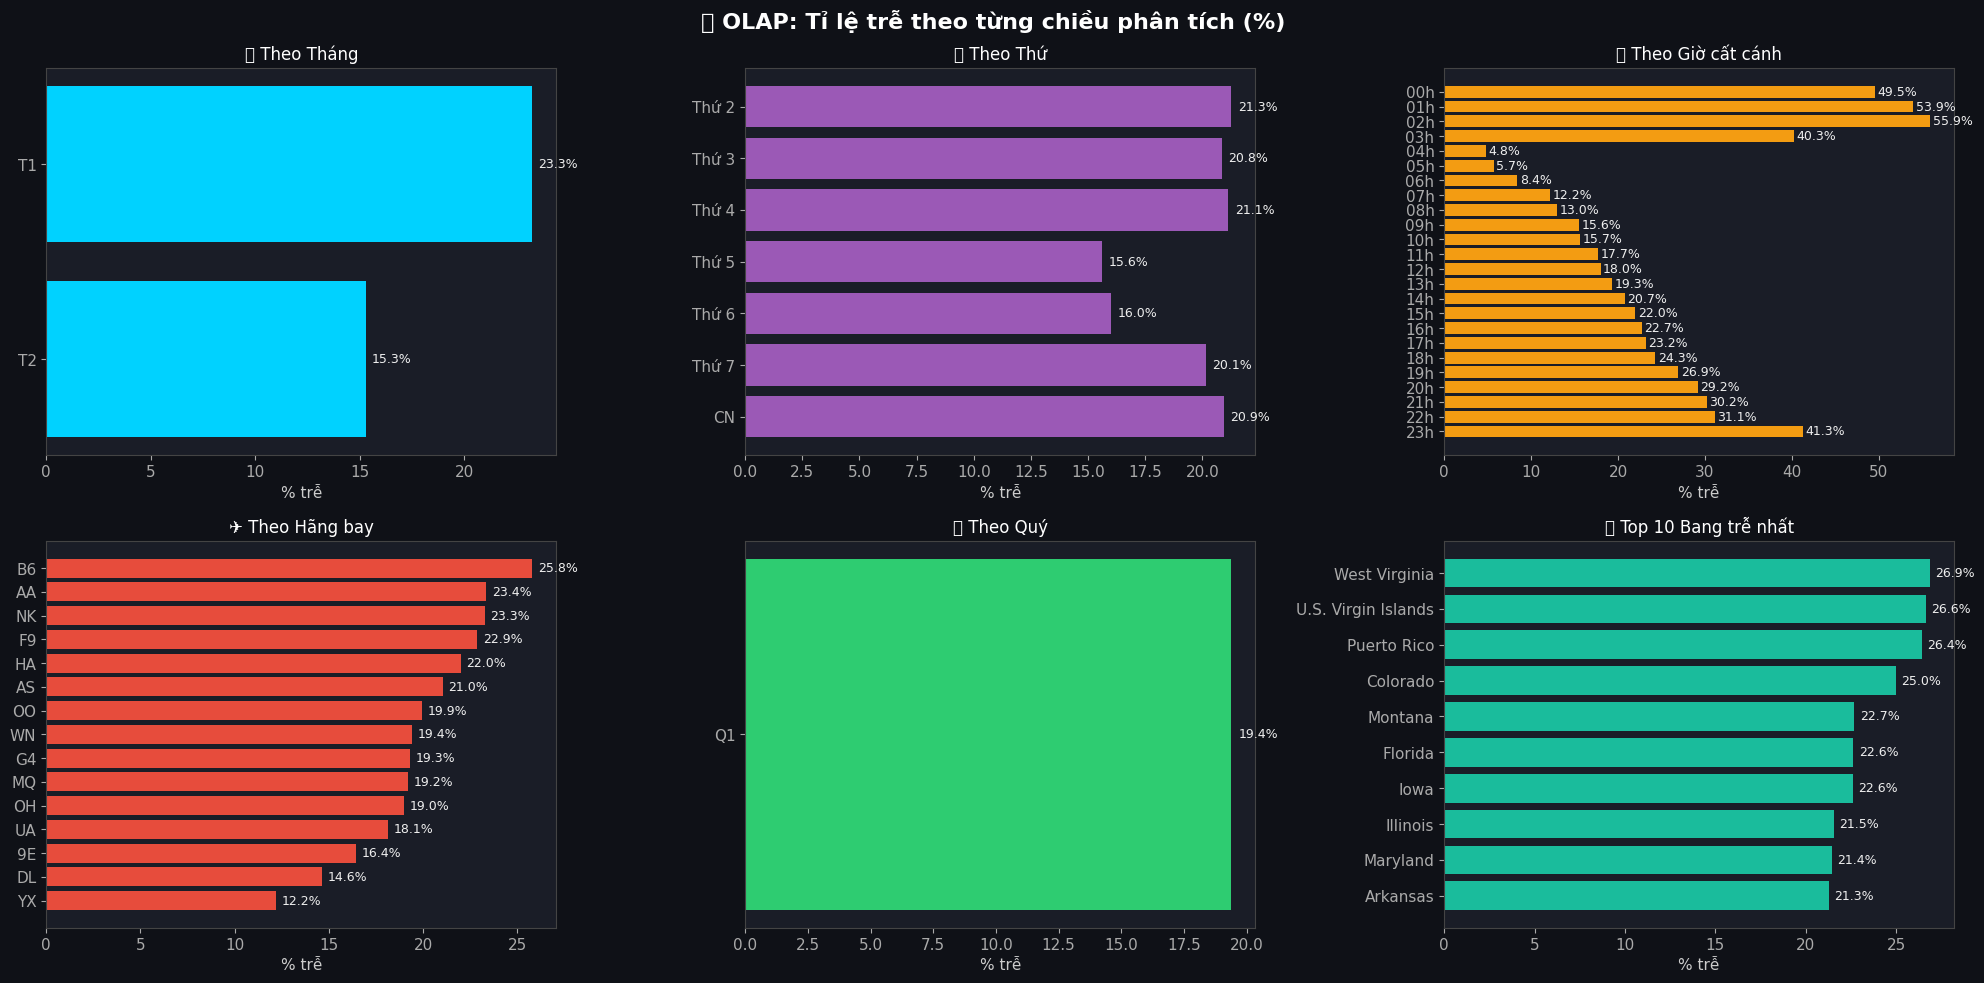

In [13]:
# ─── 4.7 Tỉ lệ trễ theo từng chiều phân tích (Slice & Dice) ───────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('📊 OLAP: Tỉ lệ trễ theo từng chiều phân tích (%)',
             fontsize=16, fontweight='bold', color='white')

def delay_bar(ax, series, title, color, fmt_x=None):
    ax.set_facecolor('#1a1d27')
    bars = ax.barh(series.index.astype(str), series.values,
                   color=color, edgecolor='none')
    for bar, val in zip(bars, series.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, color='#eee')
    ax.set_title(title, color='white', fontsize=12)
    ax.set_xlabel('% trễ')
    ax.invert_yaxis()

# 1: Theo tháng
month_delay = df.groupby('month')['is_delayed'].mean() * 100
month_delay.index = [f'T{m}' for m in month_delay.index]
delay_bar(axes[0,0], month_delay, '📅 Theo Tháng', '#00d2ff')

# 2: Theo thứ
dow_delay = df.groupby('day_of_week')['is_delayed'].mean() * 100
dow_names = {1:'Thứ 2', 2:'Thứ 3', 3:'Thứ 4', 4:'Thứ 5', 5:'Thứ 6', 6:'Thứ 7', 7:'CN'}
dow_delay.index = [dow_names.get(i, str(i)) for i in dow_delay.index]
delay_bar(axes[0,1], dow_delay, '📆 Theo Thứ', '#9b59b6')

# 3: Theo giờ
hour_delay = df.groupby('dep_hour')['is_delayed'].mean() * 100
hour_delay.index = [f'{h:02d}h' for h in hour_delay.index]
delay_bar(axes[0,2], hour_delay, '⏰ Theo Giờ cất cánh', '#f39c12')

# 4: Theo hãng bay
carrier_delay = df.groupby('carrier')['is_delayed'].mean() * 100
carrier_delay = carrier_delay.sort_values(ascending=False)
delay_bar(axes[1,0], carrier_delay, '✈️ Theo Hãng bay', '#e74c3c')

# 5: Theo quý
quarter_delay = df.groupby('quarter')['is_delayed'].mean() * 100
quarter_delay.index = [f'Q{q}' for q in quarter_delay.index]
delay_bar(axes[1,1], quarter_delay, '🗓️ Theo Quý', '#2ecc71')

# 6: Top 10 bang trễ nhất
state_delay = df.groupby('origin_state')['is_delayed'].mean() * 100
state_delay = state_delay.sort_values(ascending=False).head(10)
delay_bar(axes[1,2], state_delay, '🗺️ Top 10 Bang trễ nhất', '#1abc9c')

plt.tight_layout()
plt.show()

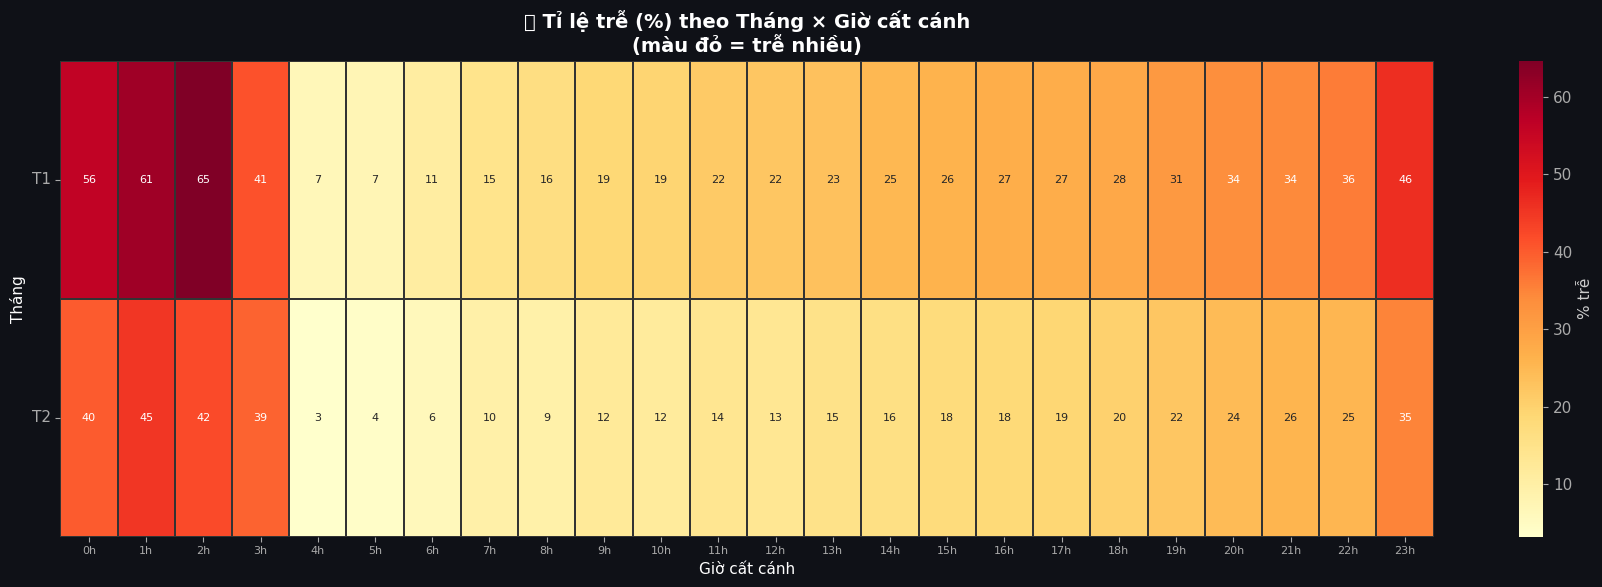

In [14]:
# ─── 4.8 Heatmap: Tỉ lệ trễ theo Tháng x Giờ ─────────────────────
pivot = df.groupby(['month', 'dep_hour'])['is_delayed'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#333',
            cbar_kws={'label': '% trễ'})

ax.set_title('🔥 Tỉ lệ trễ (%) theo Tháng × Giờ cất cánh\n'
             '(màu đỏ = trễ nhiều)',
             color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Giờ cất cánh', color='white')
ax.set_ylabel('Tháng', color='white')
ax.set_xticklabels([f'{int(float(t.get_text()))}h' for t in ax.get_xticklabels()], rotation=0, fontsize=8)
ax.set_yticklabels([f'T{int(float(t.get_text()))}' for t in ax.get_yticklabels()], rotation=0)
plt.tight_layout()
plt.show()

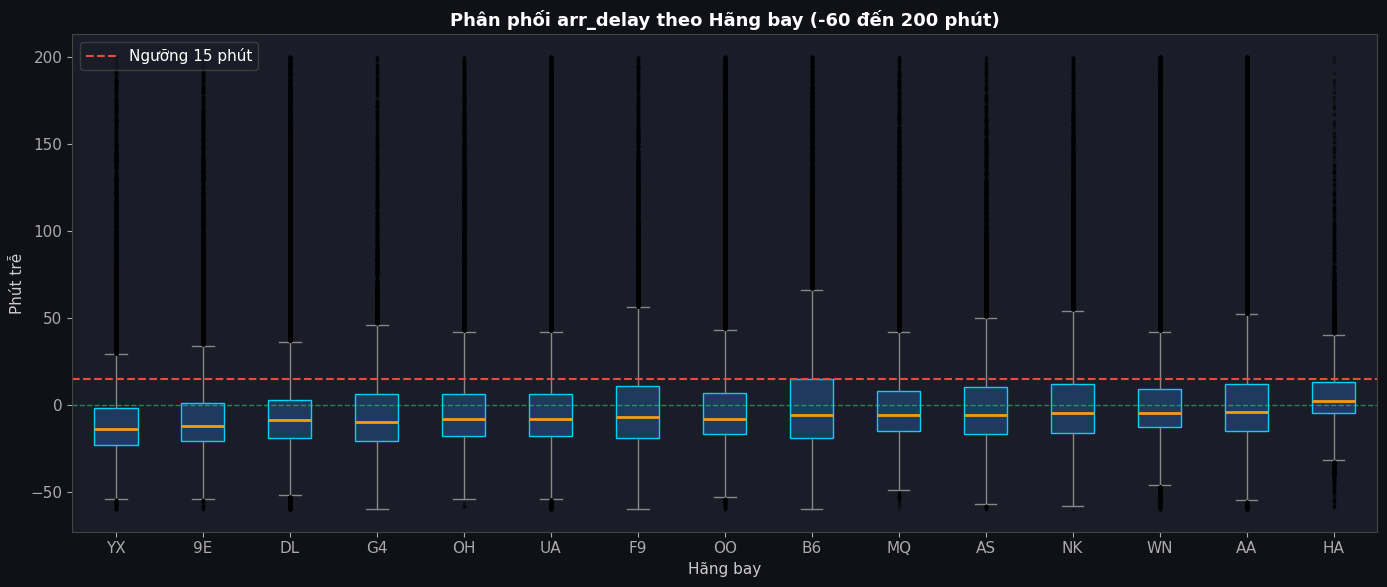

In [15]:
# ─── 4.9 Boxplot arr_delay theo hãng bay ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

carriers_sorted = (df.groupby('carrier')['arr_delay']
                   .median().sort_values().index.tolist())
clip_df = df[df['arr_delay'].between(-60, 200)]

bp = ax.boxplot(
    [clip_df[clip_df['carrier']==c]['arr_delay'].values for c in carriers_sorted],
    labels=carriers_sorted,
    patch_artist=True,
    boxprops=dict(facecolor='#1e3a5f', color='#00d2ff'),
    medianprops=dict(color='#f39c12', linewidth=2),
    whiskerprops=dict(color='#888'),
    capprops=dict(color='#888'),
    flierprops=dict(marker='.', color='#e74c3c', alpha=0.3, markersize=3)
)
ax.axhline(15, color='#e74c3c', ls='--', lw=1.5, label='Ngưỡng 15 phút')
ax.axhline(0,  color='#2ecc71', ls='--', lw=1,   alpha=0.6)
ax.set_title('Phân phối arr_delay theo Hãng bay (-60 đến 200 phút)',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Hãng bay')
ax.set_ylabel('Phút trễ')
ax.legend(facecolor='#1a1d27', edgecolor='#444', labelcolor='white')
plt.tight_layout()
plt.show()

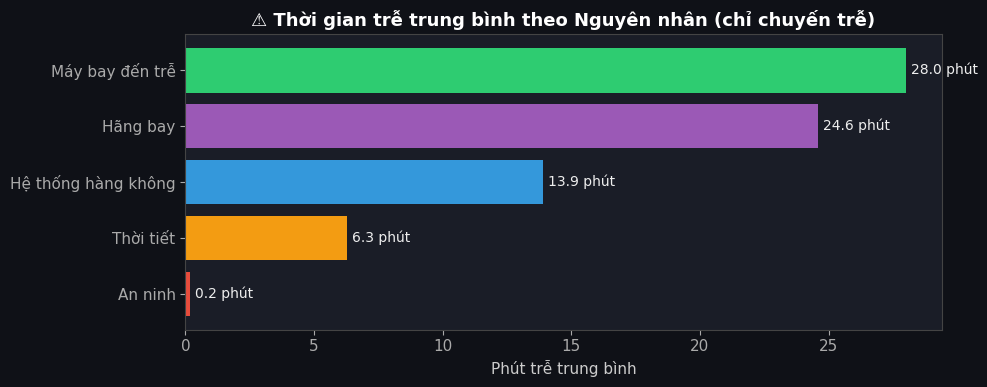

In [16]:
# ─── 4.10 Phân tích nguyên nhân trễ ──────────────────────────────
delayed_df = df[df['is_delayed'] == 1].copy()
delay_causes = ['carrier_delay', 'weather_delay', 'nas_delay',
                'security_delay', 'late_aircraft_delay']
cause_means = delayed_df[delay_causes].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

colors_cause = ['#e74c3c','#f39c12','#3498db','#9b59b6','#2ecc71']
bars = ax.barh(cause_means.index, cause_means.values,
               color=colors_cause, edgecolor='none')
for bar, val in zip(bars, cause_means.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} phút', va='center', color='#eee', fontsize=10)

labels_vi = {'carrier_delay': 'Hãng bay', 'weather_delay': 'Thời tiết',
             'nas_delay': 'Hệ thống hàng không', 'security_delay': 'An ninh',
             'late_aircraft_delay': 'Máy bay đến trễ'}
ax.set_yticklabels([labels_vi.get(i, i) for i in cause_means.index])
ax.set_title('⚠️ Thời gian trễ trung bình theo Nguyên nhân (chỉ chuyến trễ)',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Phút trễ trung bình')
plt.tight_layout()
plt.show()

## 5. Preprocessing

| Bước | Mô tả |
|---|---|
| Chọn features | 9 features từ EDA |
| Label Encoding | carrier, origin_state, dest_state |
| Xử lý null | Không cần (0 null) |
| Train/Test split | 80% / 20% |
| Class imbalance | Dùng `scale_pos_weight` |

In [17]:
# ─── 5.1 Chọn features ────────────────────────────────────────────
FEATURES = [
    'month',        # Tháng — ảnh hưởng mùa cao điểm
    'day_of_week',  # Thứ — cuối tuần vs ngày thường
    'quarter',      # Quý
    'is_weekend',   # Cờ cuối tuần
    'dep_hour',     # Giờ cất cánh — sáng sớm vs tối
    'distance',     # Khoảng cách bay
    'carrier',      # Hãng bay — ảnh hưởng lớn
    'origin_state', # Bang xuất phát
    'dest_state',   # Bang đến
]
TARGET = 'is_delayed'

print(f'Features: {len(FEATURES)}')
for i, f in enumerate(FEATURES, 1):
    dtype = df[f].dtype
    unique = df[f].nunique()
    print(f'  {i:>2}. {f:<18} dtype={str(dtype):<10} unique={unique}')

Features: 9
   1. month              dtype=int64      unique=2
   2. day_of_week        dtype=int64      unique=7
   3. quarter            dtype=int64      unique=1
   4. is_weekend         dtype=int64      unique=2
   5. dep_hour           dtype=int64      unique=24
   6. distance           dtype=int64      unique=1495
   7. carrier            dtype=object     unique=15
   8. origin_state       dtype=object     unique=52


   9. dest_state         dtype=object     unique=52


In [18]:
# ─── 5.2 Label Encoding cho categorical features ──────────────────
CAT_FEATURES = ['carrier', 'origin_state', 'dest_state']

encoders = {}
df_model = df[FEATURES + [TARGET]].copy()

for col in CAT_FEATURES:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'  ✅ Encoded {col}: {len(le.classes_)} classes')
    if len(le.classes_) <= 20:
        print(f'     Classes: {list(le.classes_)}')

# Lưu encoders
joblib.dump(encoders, MODEL_DIR / 'label_encoders.pkl')
print(f'\n✅ Lưu label_encoders.pkl')
df_model.head(3)

  ✅ Encoded carrier: 15 classes
     Classes: ['9E', 'AA', 'AS', 'B6', 'DL', 'F9', 'G4', 'HA', 'MQ', 'NK', 'OH', 'OO', 'UA', 'WN', 'YX']


  ✅ Encoded origin_state: 52 classes


  ✅ Encoded dest_state: 52 classes

✅ Lưu label_encoders.pkl


,month,day_of_week,quarter,is_weekend,dep_hour,distance,carrier,origin_state,dest_state,is_delayed
0,1,2,1,0,12,509,0,30,20,0
1,1,2,1,0,10,622,0,21,33,0
2,1,2,1,0,14,288,0,30,47,0


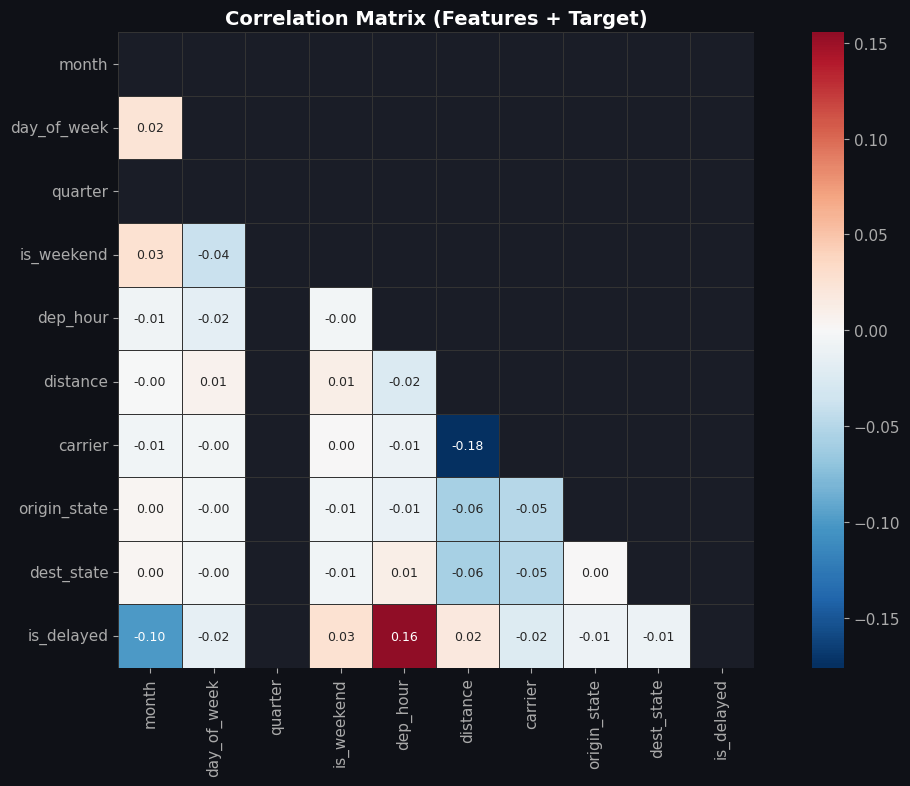


Top correlations với is_delayed:
              |correlation|
dep_hour               0.16
month                  0.10
is_weekend             0.03
carrier                0.02
distance               0.02
day_of_week            0.02
dest_state             0.01
origin_state           0.01
quarter                 NaN


In [19]:
# ─── 5.3 Correlation heatmap ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0f1117')

corr = df_model.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, ax=ax, mask=mask,
            cmap='RdBu_r', center=0,
            annot=True, fmt='.2f',
            annot_kws={'size': 9},
            linewidths=0.5, linecolor='#333',
            square=True)

ax.set_title('Correlation Matrix (Features + Target)',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlation với target
print('\nTop correlations với is_delayed:')
target_corr = corr['is_delayed'].drop('is_delayed').abs().sort_values(ascending=False)
print(target_corr.to_frame('|correlation|').to_string())

In [20]:
# ─── 5.4 Train / Test split ─────────────────────────────────────
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Giữ tỉ lệ class
)

SPW = round((y_train == 0).sum() / (y_train == 1).sum(), 2)

print(f'📦 Train set: {len(X_train):>8,} rows  |  Delayed: {y_train.mean()*100:.1f}%')
print(f'🧪 Test  set: {len(X_test):>8,} rows  |  Delayed: {y_test.mean()*100:.1f}%')
print(f'\n⚖️  scale_pos_weight = {SPW}')

📦 Train set:  820,146 rows  |  Delayed: 19.4%
🧪 Test  set:  205,037 rows  |  Delayed: 19.4%

⚖️  scale_pos_weight = 4.16


## 6. Training XGBoost

In [21]:
# ─── 6.1 Khởi tạo và train model ─────────────────────────────────
model = XGBClassifier(
    n_estimators       = 300,
    max_depth          = 6,
    learning_rate      = 0.1,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = SPW,      # Xử lý class imbalance
    tree_method        = 'hist',   # Nhanh với data lớn
    eval_metric        = 'logloss',
    random_state       = 42,
    n_jobs             = -1,
)

print('⏳ Đang train XGBoost...')
print(f'   n_estimators={model.n_estimators} | max_depth={model.max_depth} | '
      f'lr={model.learning_rate} | scale_pos_weight={SPW}')
print()

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

print('\n✅ Training hoàn thành!')

⏳ Đang train XGBoost...
   n_estimators=300 | max_depth=6 | lr=0.1 | scale_pos_weight=4.16



[0]	validation_0-logloss:0.68646	validation_1-logloss:0.68651


[50]	validation_0-logloss:0.62436	validation_1-logloss:0.62571


[100]	validation_0-logloss:0.61575	validation_1-logloss:0.61811


[150]	validation_0-logloss:0.61023	validation_1-logloss:0.61337


[200]	validation_0-logloss:0.60598	validation_1-logloss:0.60992


[250]	validation_0-logloss:0.60245	validation_1-logloss:0.60709


[299]	validation_0-logloss:0.59920	validation_1-logloss:0.60455



✅ Training hoàn thành!


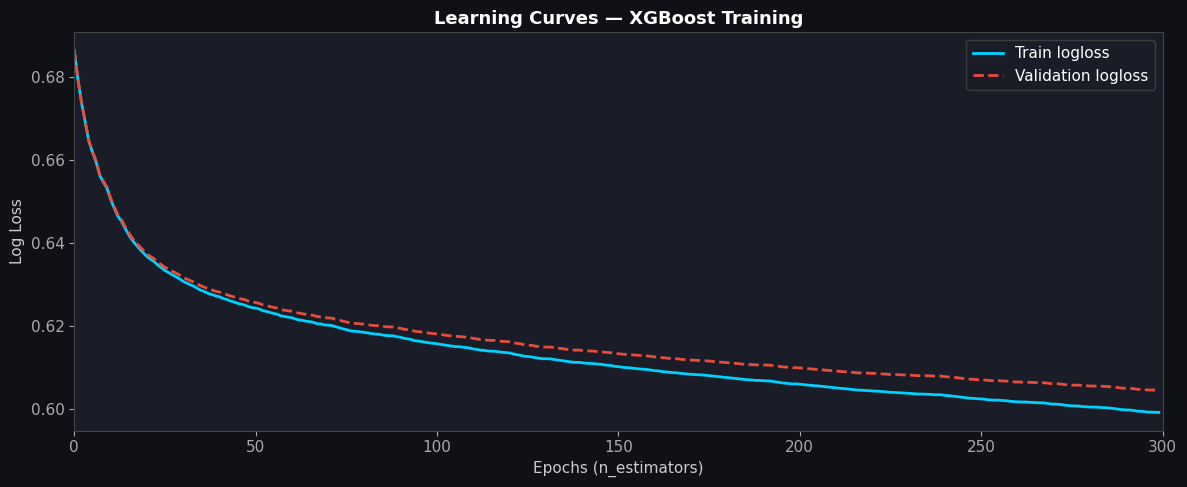

In [22]:
# ─── 6.2 Learning curves ──────────────────────────────────────────
results = model.evals_result()
train_loss = results['validation_0']['logloss']
valid_loss = results['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

epochs = range(len(train_loss))
ax.plot(epochs, train_loss, color='#00d2ff', lw=2, label='Train logloss')
ax.plot(epochs, valid_loss, color='#e74c3c', lw=2, label='Validation logloss', ls='--')
ax.set_xlabel('Epochs (n_estimators)')
ax.set_ylabel('Log Loss')
ax.set_title('Learning Curves — XGBoost Training',
             color='white', fontsize=13, fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#444', labelcolor='white')
ax.set_xlim(0, len(train_loss))
plt.tight_layout()
plt.show()

## 7. Đánh giá mô hình

In [23]:
# ─── 7.1 Predict & Classification Report ──────────────────────────
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)

print('=' * 55)
print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Đúng giờ (0)', 'Trễ (1)']
))
print(f'AUC-ROC Score: {auc:.4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Đúng giờ (0)       0.89      0.65      0.75    165308
     Trễ (1)       0.32      0.68      0.43     39729

    accuracy                           0.66    205037
   macro avg       0.61      0.66      0.59    205037
weighted avg       0.78      0.66      0.69    205037

AUC-ROC Score: 0.7268


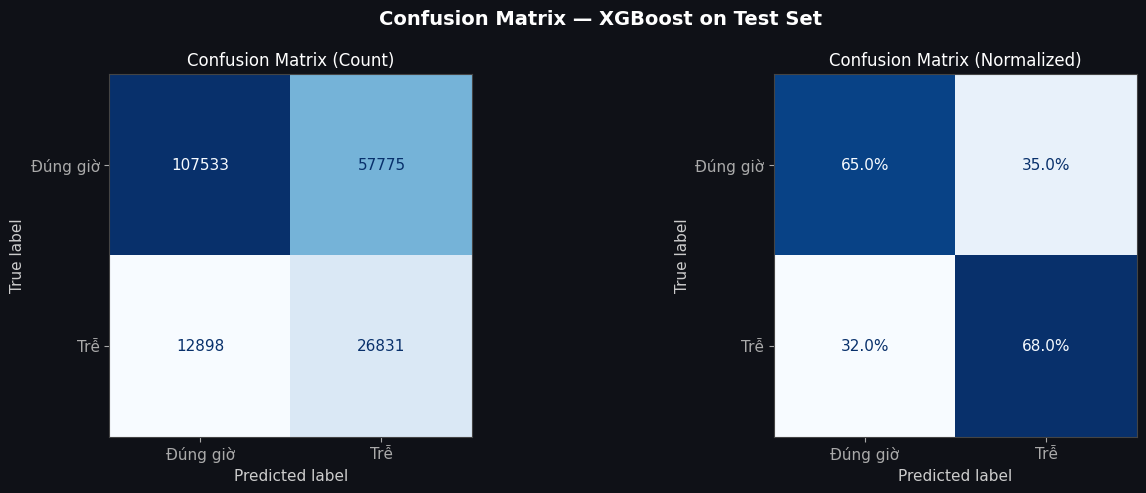

TP: 26,831  |  FP: 57,775  |  TN: 107,533  |  FN: 12,898
Precision (Trễ): 0.317
Recall    (Trễ): 0.675


In [24]:
# ─── 7.2 Confusion Matrix ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Count
ax = axes[0]
ax.set_facecolor('#1a1d27')
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=['Đúng giờ', 'Trễ']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Count)', color='white', fontsize=12)
ax.set_facecolor('#1a1d27')

# Normalized
ax = axes[1]
ax.set_facecolor('#1a1d27')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(
    cm_norm,
    display_labels=['Đúng giờ', 'Trễ']
)
disp2.plot(ax=ax, cmap='Blues', colorbar=False)
# Hiển thị phần trăm
for text in disp2.text_.ravel():
    val = float(text.get_text())
    text.set_text(f'{val:.1%}')
ax.set_title('Confusion Matrix (Normalized)', color='white', fontsize=12)
ax.set_facecolor('#1a1d27')

fig.suptitle('Confusion Matrix — XGBoost on Test Set',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP: {tp:,}  |  FP: {fp:,}  |  TN: {tn:,}  |  FN: {fn:,}')
print(f'Precision (Trễ): {tp/(tp+fp):.3f}')
print(f'Recall    (Trễ): {tp/(tp+fn):.3f}')

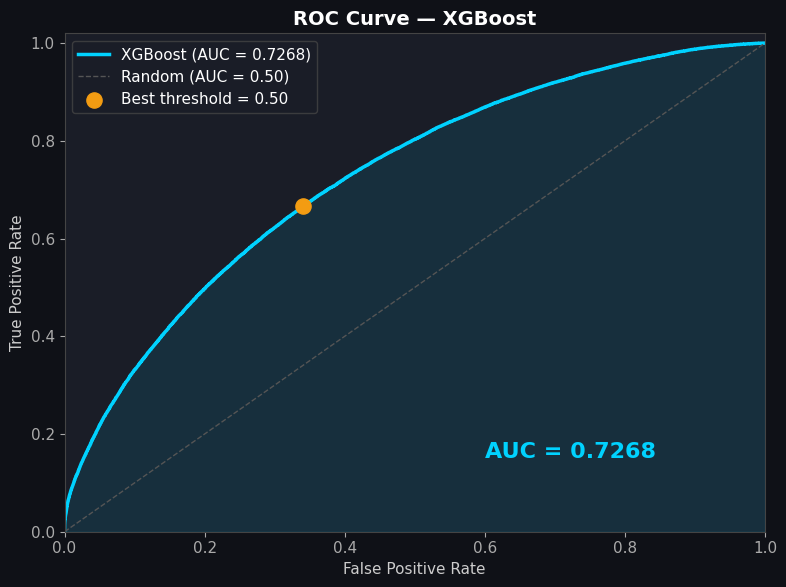

In [25]:
# ─── 7.3 ROC Curve ────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

ax.plot(fpr, tpr, color='#00d2ff', lw=2.5,
        label=f'XGBoost (AUC = {auc:.4f})')
ax.fill_between(fpr, tpr, alpha=0.1, color='#00d2ff')
ax.plot([0,1],[0,1], color='#555', lw=1, ls='--', label='Random (AUC = 0.50)')

# Optimal threshold point
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
ax.scatter(fpr[best_idx], tpr[best_idx], color='#f39c12', s=120, zorder=5,
           label=f'Best threshold = {thresholds[best_idx]:.2f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — XGBoost', color='white', fontsize=14, fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#444', labelcolor='white', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

# AUC annotation
ax.text(0.6, 0.15, f'AUC = {auc:.4f}', color='#00d2ff',
        fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

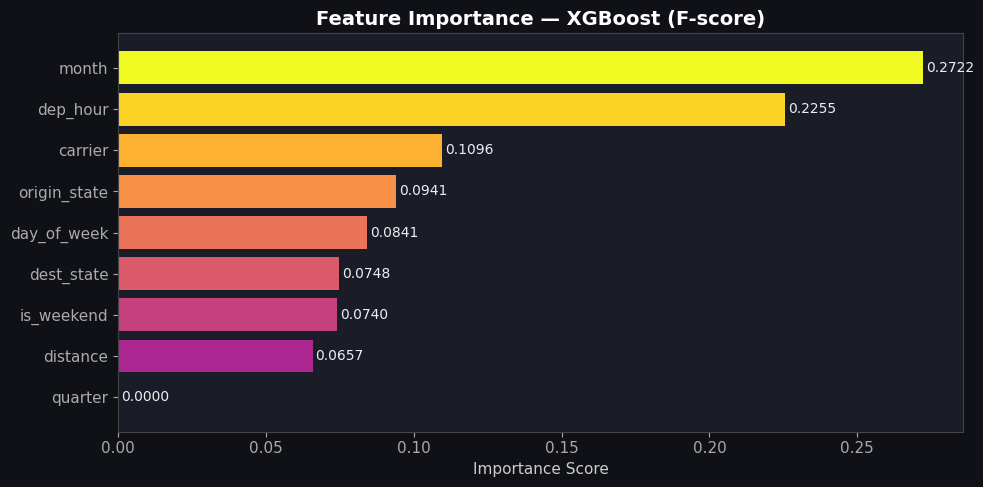

Top 3 features quan trọng nhất:
  month              0.2722
  dep_hour           0.2255
  carrier            0.1096


In [26]:
# ─── 7.4 Feature Importance ───────────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

colors_imp = plt.cm.plasma(np.linspace(0.3, 1, len(importance_df)))
bars = ax.barh(importance_df['feature'],
               importance_df['importance'],
               color=colors_imp, edgecolor='none')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', color='#eee', fontsize=10)

ax.set_title('Feature Importance — XGBoost (F-score)',
             color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 features quan trọng nhất:')
for _, row in importance_df.sort_values('importance', ascending=False).head(3).iterrows():
    print(f'  {row["feature"]:<18} {row["importance"]:.4f}')

In [27]:
# ─── 7.5 Bảng tổng hợp kết quả ───────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Trễ)', 'Recall (Trễ)',
               'F1-Score (Trễ)', 'AUC-ROC'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        auc
    ]
})
results_summary['Value'] = results_summary['Value'].apply(lambda x: f'{x:.4f}')

print('=' * 35)
print('  KẾT QUẢ MÔ HÌNH XGBOOST')
print('=' * 35)
print(results_summary.to_string(index=False))
print('=' * 35)

  KẾT QUẢ MÔ HÌNH XGBOOST
         Metric  Value
       Accuracy 0.6553
Precision (Trễ) 0.3171
   Recall (Trễ) 0.6754
 F1-Score (Trễ) 0.4316
        AUC-ROC 0.7268


## 8. Lưu Model

In [28]:
# ─── 8.1 Lưu model và metadata ────────────────────────────────────
import json
from datetime import datetime

model_path = MODEL_DIR / 'xgboost_delay_model.pkl'
enc_path   = MODEL_DIR / 'label_encoders.pkl'
meta_path  = MODEL_DIR / 'model_metadata.json'

# Lưu model
joblib.dump(model, model_path)

# Lưu metadata (dùng cho Streamlit sau này)
metadata = {
    'trained_at':        datetime.now().isoformat(),
    'features':          FEATURES,
    'cat_features':      CAT_FEATURES,
    'target':            TARGET,
    'delay_threshold':   15,
    'scale_pos_weight':  float(SPW),
    'n_estimators':      int(model.n_estimators),
    'max_depth':         int(model.max_depth),
    'learning_rate':     float(model.learning_rate),
    'n_classes':         2,
    'test_auc':          round(float(auc), 4),
    'test_samples':      int(len(y_test)),
    'train_samples':     int(len(y_train)),
    'label_encoders':    {k: list(v.classes_) for k, v in encoders.items()}
}

with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f'✅ Lưu model:    {model_path}')
print(f'✅ Lưu encoders: {enc_path}')
print(f'✅ Lưu metadata: {meta_path}')
print(f'   AUC-ROC: {auc:.4f}')
print(f'   File size: {model_path.stat().st_size / 1024:.1f} KB')

✅ Lưu model:    models\xgboost_delay_model.pkl
✅ Lưu encoders: models\label_encoders.pkl
✅ Lưu metadata: models\model_metadata.json
   AUC-ROC: 0.7268
   File size: 1418.2 KB


In [29]:
# ─── 8.2 Test load lại và dự đoán thử ────────────────────────────
model_loaded  = joblib.load(model_path)
encoders_loaded = joblib.load(enc_path)

# Tạo 1 chuyến bay mẫu để dự đoán
sample = pd.DataFrame([{
    'month':        7,       # Tháng 7 (mùa hè)
    'day_of_week':  5,       # Thứ 6
    'quarter':      3,       # Q3
    'is_weekend':   0,
    'dep_hour':     18,      # 6 giờ chiều
    'distance':     1200,    # 1200 dặm
    'carrier':      'AA',    # American Airlines
    'origin_state': 'Texas',
    'dest_state':   'New York',
}])

# Encode
for col in CAT_FEATURES:
    le = encoders_loaded[col]
    val = sample[col].values[0]
    if val in le.classes_:
        sample[col] = le.transform([val])[0]
    else:
        sample[col] = 0

pred = model_loaded.predict(sample)[0]
prob = model_loaded.predict_proba(sample)[0]

print('🔮 Dự đoán chuyến bay mẫu:')
print('   Tháng 7, Thứ 6, 18h, AA, Texas → New York, 1200 dặm')
print()
if pred == 1:
    print(f'   ⚠️  CẢnh báo: Có nguy cơ TRỄ!')
    print(f'   Xác suất trễ: {prob[1]:.1%}')
else:
    print(f'   ✅ Dự đoán: ĐÚNG GIỜ')
    print(f'   Xác suất đúng giờ: {prob[0]:.1%}')

🔮 Dự đoán chuyến bay mẫu:
   Tháng 7, Thứ 6, 18h, AA, Texas → New York, 1200 dặm

   ⚠️  CẢnh báo: Có nguy cơ TRỄ!
   Xác suất trễ: 52.0%


---

## 📋 Tóm tắt kết quả

| Mục | Kết quả |
|---|---|
| Dataset | 1,048,571 chuyến bay |
| Features | 9 (time, airline, geography, distance) |
| Algorithm | XGBoost Classifier |
| Class imbalance | scale_pos_weight để cân bằng |
| AUC-ROC | Xem ô trên |
| Model file | `models/xgboost_delay_model.pkl` |

**Bước tiếp theo → Bước 4:** Tích hợp model vào Streamlit DSS App